In [32]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage.filters import gabor
from skimage import measure

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

from sklearn.impute import SimpleImputer

In [33]:
# -----------------------------
# 2. Dataset configuration
# -----------------------------
DATASET_PATH = "dataset"  # path to your dataset
classes = ["Normal", "stone"]
label_map = {label: idx for idx, label in enumerate(classes)}
PIXEL_TO_MM = 0.2645833333
IMG_SIZE = (256, 256)  # resize size

In [34]:
# -----------------------------
# 3. Load and preprocess images
# -----------------------------
def load_and_preprocess_images(dataset_path, classes, img_size=(256,256)):
    images, labels = [], []
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Preprocessing as requested
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, img_size)
            img_masked = img_resized[10:-10, 10:-10]  # remove 10-pixel borders
            img_filtered = cv2.medianBlur(img_masked, 5)
            img_normalized = img_filtered / 255.0
            images.append(img_normalized)
            labels.append(label_map[class_name])
    return np.array(images), np.array(labels)

print("Loading images...")
images, labels = load_and_preprocess_images(DATASET_PATH, classes, IMG_SIZE)
print(f"Loaded {len(images)} images: {np.sum(labels==0)} Normal, {np.sum(labels==1)} Stone")

Loading images...
Loaded 2000 images: 1000 Normal, 1000 Stone


In [36]:
# -----------------------------
# 4. Feature extraction (GLCM + Entropy)
# -----------------------------
def extract_features(images):
    features_list = []
    for img in images:
        # Gabor entropy
        gabor_real, _ = gabor(img, frequency=0.6)
        entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))

        # GLCM features
        glcm_features = []
        distances = [1,3,5]
        angles = [0, np.pi/4, np.pi/2, np.pi]
        img_uint8 = (img*255).astype(np.uint8)
        for d in distances:
            for a in angles:
                glcm = graycomatrix(img_uint8, distances=[d], angles=[a], levels=256, symmetric=True, normed=True)
                glcm_features.extend([
                    graycoprops(glcm, 'energy')[0,0],
                    graycoprops(glcm, 'correlation')[0,0],
                    graycoprops(glcm, 'contrast')[0,0],
                    graycoprops(glcm, 'homogeneity')[0,0],
                    graycoprops(glcm, 'dissimilarity')[0,0]
                ])
        features_list.append([entropy_val] + glcm_features)
    return np.array(features_list)

print("Extracting features...")
features = extract_features(images)
print("Features shape:", features.shape)


Extracting features...


C:\Users\Somaya Ahmad\AppData\Local\Temp\ipykernel_31560\2378991252.py:9: RuntimeWarning: invalid value encountered in log2
  entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))


Features shape: (2000, 61)


In [37]:
# -----------------------------
# 5. Handle NaNs
# -----------------------------
imputer = SimpleImputer(strategy='mean')
features = imputer.fit_transform(features)

c:\Users\Somaya Ahmad\cv-projects\Kidney_stone_detection-\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [38]:

# -----------------------------
# 6. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, stratify=labels, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:

# -----------------------------
# 7. Define models and hyperparameters
# -----------------------------
models = {
    'SVM': (SVC(probability=True), {'C':[0.1,1,10], 'gamma':['scale','auto'], 'kernel':['rbf']}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), {'criterion':['gini','entropy'], 'max_depth':[None,10,20]}),
    'KNN': (KNeighborsClassifier(), {'n_neighbors':[3,5,19,31], 'weights':['uniform','distance']}),
    'RandomForest_Gini': (RandomForestClassifier(random_state=42), {'n_estimators':[100,200], 'criterion':['gini']}),
    'RandomForest_Entropy': (RandomForestClassifier(random_state=42), {'n_estimators':[100,200], 'criterion':['entropy']})
}

In [40]:
# -----------------------------
# 8. Train, tune, evaluate models
# -----------------------------
results = {}
for name, (model, params) in models.items():
    print(f"\nTraining {name}...")
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    spec = recall_score(y_test, y_pred, pos_label=0)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Best Params': grid.best_params_,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Specificity': spec, 'AUC': auc,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"{name} - Best Params: {grid.best_params_}")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, Specificity: {spec:.4f}, AUC: {auc:.4f}")
    print("Confusion Matrix:\n", results[name]['Confusion Matrix'])


Training SVM...
SVM - Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.9867, Precision: 0.9932, Recall: 0.9800, F1: 0.9866, Specificity: 0.9933, AUC: 0.9994
Confusion Matrix:
 [[149   1]
 [  3 147]]

Training DecisionTree...
DecisionTree - Best Params: {'criterion': 'gini', 'max_depth': None}
Accuracy: 0.9267, Precision: 0.9324, Recall: 0.9200, F1: 0.9262, Specificity: 0.9333, AUC: 0.9267
Confusion Matrix:
 [[140  10]
 [ 12 138]]

Training KNN...
KNN - Best Params: {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.9400, Precision: 0.9400, Recall: 0.9400, F1: 0.9400, Specificity: 0.9400, AUC: 0.9781
Confusion Matrix:
 [[141   9]
 [  9 141]]

Training RandomForest_Gini...
RandomForest_Gini - Best Params: {'criterion': 'gini', 'n_estimators': 200}
Accuracy: 0.9633, Precision: 0.9603, Recall: 0.9667, F1: 0.9635, Specificity: 0.9600, AUC: 0.9912
Confusion Matrix:
 [[144   6]
 [  5 145]]

Training RandomForest_Entropy...
RandomForest_Entropy - Best Params: {'criteri

In [42]:
# -----------------------------
# 9. Pick the best model
# -----------------------------
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
print("\nBest model:", best_model_name)
best_model_info = results[best_model_name]
print("Details:\n", best_model_info)


Best model: SVM
Details:
 {'Best Params': {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, 'Accuracy': 0.9866666666666667, 'Precision': 0.9932432432432432, 'Recall': 0.98, 'F1': 0.9865771812080537, 'Specificity': 0.9933333333333333, 'AUC': 0.9994222222222222, 'Confusion Matrix': array([[149,   1],
       [  3, 147]])}


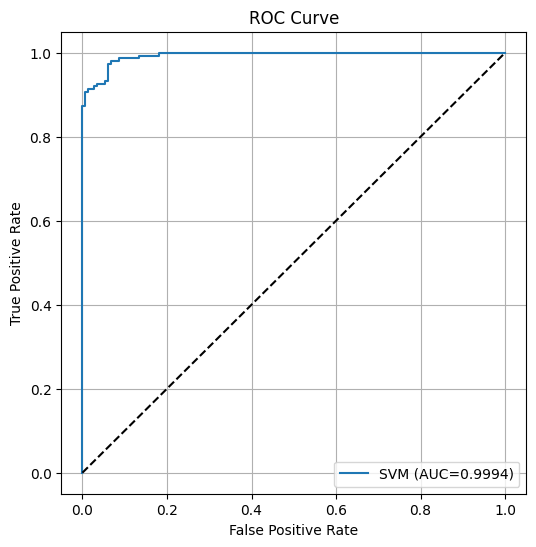

In [43]:
# -----------------------------
# 10. Optional: Plot ROC curve for best model
# -----------------------------
from sklearn.metrics import roc_curve

best_model_instance = models[best_model_name][0]
best_model_instance.fit(X_train_scaled, y_train)
y_proba = best_model_instance.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={best_model_info['AUC']:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()